---
title: "HDA Climate DT Parameter Plotter - Tutorial"
subtitle: "This notebook provides an interactive workflow to select, query, download, and visualize Climate Digital Twin parameters from the DestinE Data Lake using the DEDL HDA API."
author: "Michael Schick (EUMETSAT), Serena Avolio (EUMETSAT/Starion)"
tags: [HDA, ECMWF, earthkit, Digital Twin]
thumbnail: ../../img/ECMWF.png
license: MIT
copyright: "© 2025 EUMETSAT"
---
<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/HDA/DestinE_Digital_Twins/ClimateDT-ParameterPlotter.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

# HDA Climate DT Parameter Plotter - Tutorial

<div class="alert alert-block alert-warning">
<b> Prerequisites: </b><ul>
   <li>To search and access DEDL data a <a href="https://platform.destine.eu/"> DestinE user account</a> is needed</li>
   <li>To search and access DT data an <a href="https://platform.destine.eu/support-pages/access-policy/"> upgraded access</a> is needed.</li></ul>
<b> References: </b><ul>
    <li><a href="https://destine-data-lake-docs.data.destination-earth.eu/en/latest/dedl-discovery-and-data-access/Use-of-Harmonized-Data-Access/Use-of-Harmonized-Data-Access.html">DestinE Data Lake (DEDL) Harmonized Data Access (HDA) documentation</a> </li>
    <li> <a href="https://destine.ecmwf.int/climate-change-adaptation-digital-twin-climate-dt/">Climate Change Adaptation DT (Climate DT)</a></li> 
    <li> <a href="https://platform.destine.eu/services/documents-and-api/doc/?service_name=climate-dt-user-guide">Climate DT user guide</a></li> 
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/DestinE+ClimateDT+Phase+2+Parameters">Climate DT parameters for phase II</a></li> 
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/Climate+DT+Phase+1+data+catalogue">Climate DT data catalogue for phase I</a></li>
    <li> <a href="https://confluence.ecmwf.int/display/DDCZ/DestinE+ClimateDT+Parameters">Climate DT parameters for phase I</a></li> </ul>
<b> Credit: </b><ul>
    <li> Earthkit and Polytope (used from HDA) are both packages provided by the European Centre for Medium-Range Weather Forecasts (ECMWF).</li></ul>
</div>

**This notebook demonstrates how to access Climate DT data via HDA (Harmonized Data Access) API for different types of Climate DT simulations.**

The DestinE Digital Twin for Climate Change Adaptation (Climate DT) supports adaptation activities by providing innovative climate information on multi-decadal timescales, globally, at scales at which many impacts of climate change are observed.

Climate Digital Twin (DT) datasets are available across various simulation types and parameter configurations.

This notebook is designed to help you navigate these options and provides guidance for constructing the appropriate HDA request to access and visualize the Climate DT data relevant to your needs.




**The workflow covered by this notebook, depicted in the image below,  starts from STAC Discovery of collections and parameters to the Execution of a Polytope request via HDA**


![HDA Diagram](img/climatePlotter.svg)

Below the main steps covered by this tutorial.

1. [Setup](#ClimateDT-ParameterPlotter.ipynb-Setup): Import the required libraries and define some function. 
2. [Simulation Selection - Discover Climate DT collections](#ClimateDT-ParameterPlotter.ipynb-Simulation-Selection):  Print and select the desired simulation for accessing Climate DT data.  
3. [Parameter Selection - Discover query parameters](#ClimateDT-ParameterPlotter.ipynb-Parameter-Selection): How to select the desired Climate DT variable among the ones available through the selected simulation.
4. [Parameter Available Dimensions Selection - Discover query parameters](#ClimateDT-ParameterPlotter.ipynb-Levels-Selection): How to Handle different Levels to be selected (if any).
5. [Search, Order and Download - From Search to Order and Access Climate DT data](#ClimateDT-ParameterPlotter.ipynb-Order-and-Download): How to order and download Climate DT data.
6. [Plot](#ClimateDT-ParameterPlotter.ipynb-EarthKit): How to visualize hourly data on single levels data through Earthkit.

(ClimateDT-ParameterPlotter.ipynb-Setup)=
## Setup

In [1]:
pip install --user --quiet --upgrade destinelab

Note: you may need to restart the kernel to use updated packages.


Import the required packages and define some constants.

In [2]:
import destinelab as deauth
import json
from datetime import date, datetime, timedelta

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import os
import re
from getpass import getpass
from tqdm import tqdm
import time
from IPython.display import JSON, display, HTML

import pandas as pd
import ipywidgets as w

Define some funtions to show info when a value in a widget is selected and to store the selection.

In [3]:

# parse STAC temporal interval into date objects
def parse_time_extent(interval_string):
    start_iso, end_iso = interval_string.split()
    to_date = lambda s: (datetime.fromisoformat(s.replace("Z","")).date() if s else None)
    sd, ed = to_date(start_iso), to_date(end_iso)
    s_txt = sd.isoformat() if sd else "open"
    e_txt = ed.isoformat() if ed else "open"
    return sd, ed, f"{s_txt} → {e_txt}"


#show the info of the selected variable
def show_variable_info(change):
    q = combo.value.lower()
    with out:
        out.clear_output()
        # Find all keys containing the query
        matches = [k for k in keys if q in k.lower()]
        # Print matching keys
        for k in matches:
            print(k)

        # Trigger variable info if only one match exists
        if len(matches) == 1:

            selected_key = matches[0]

            var = collection_json["cube:variables"][selected_key]

            attrs = var.get("attrs", {})

            selected["name"]         = selected_key
            selected["parameter_ID"] = attrs.get("parameter_ID")
            selected["levtype"]      = attrs.get("levtype")
            selected["time"]         = attrs.get("time")
            selected["levelist"]     = attrs.get("levelist")
            selected["stream"]     = attrs.get("stream")

            print(json.dumps(attrs, indent=2))

            print("\nSaved selection:")
            print({k: selected[k] for k in ["name","parameter_ID","levtype","time","stream"]})

#shows dates selection
def refresh(change=None):
    selected["chosen_date"] = dp.value or (selected_collection["start_date"] or date.today())
    dt = datetime(selected["chosen_date"].year, selected["chosen_date"].month, selected["chosen_date"].day, 00, 00)
    out2.value = f"<ul><li><b>Collection:</b> {selected_collection['id']}</li><li><b>DateTime(UTC):</b> {dt.isoformat()}Z</li>"
       
#shows hours and levels selection
def refresh_hl(_=None):
    # Persist hour (if shown)
    if hour_dd is not None:
        selected["hour"] = hour_dd.value  # e.g., "14:00"
    else:
        selected.pop("hour", None)

    # Persist selected levels as a list (if shown)
    if levels_ms is not None:
        selected["levels"] = list(levels_ms.value)  # e.g., ["11","100"]
    else:
        selected.pop("levels", None)
    
    with out:
        out.clear_output()
        print(f"Variable: {selected.get('name')}")
        print(f"Time: {selected.get('time')}  |  Levtype: {selected.get('levtype')}")
        if "hour" in selected:
            print(f"Selected hour: {selected['hour']}")
        if "levels" in selected:
            print(f"Selected levels: {selected['levels'] if selected['levels'] else '(none)'}")
        if "year" in selected:
            print(f"Selected year: {selected['year']}")
        if "month" in selected:
            print(f"Selected month: {selected['month'] if selected['month'] else '(none)'}")
        if levels_ms is None:
            print("No levels selector (no 'levelist' provided).")

            
def on_generation_change(change):
    with output:
        output.clear_output()
        df = discover_climate_dt(change["new"].split("/")[0],change["new"].split("/")[1])
        # store values
        selected_collection["df"] = df
        display(HTML(df.drop(columns=["HDA - Climate DT descripton"]).to_html(index=False)))


def on_collection_change(change):

    if change["name"] == "value" and change["type"] == "change":
        title, collection_id, description, time_extension = change["new"]


        # store values
        selected_collection["title"] = title
        selected_collection["id"] = collection_id
        selected_collection["description"] = description
        selected_collection["time"] = time_extension
        sd, ed, extent_txt = parse_time_extent(time_extension)
        selected_collection["start_date"] = sd
        selected_collection["end_date"] = ed
        
        
        with out:
            out.clear_output()
            print("Selected collection title:\n--------------")
            print(title if title else "(no title)")
            print("\n\nSelected collection  ID\n--------------")
            print(collection_id if collection_id else "(no ID)")
            print("\n\nSelected collection  description\n--------------")
            print(description if description else "(no description)")
            print("\n\nTime extent:\n--------------")
            print(time_extension)
            refresh()

define some useful constants

In [4]:
HDA_STAC_ENDPOINT="https://hda.data.destination-earth.eu/stac/v2"
print("STAC endpoint: ", HDA_STAC_ENDPOINT)
HDA_DISCOVERY_ENDPOINT = HDA_STAC_ENDPOINT+'/collections'
print("HDA discovery endpoint: ", HDA_DISCOVERY_ENDPOINT)

STAC endpoint:  https://hda.data.destination-earth.eu/stac/v2
HDA discovery endpoint:  https://hda.data.destination-earth.eu/stac/v2/collections


(ClimateDT-ParameterPlotter.ipynb-Scenario-Simulation-Selection)=
## Simulation Selection  - Discover Climate DT collections

**Within the HDA, the various Climate DT simulations are organized as separate STAC collections.**
Consequently, accessing Climate DT simulation data through the HDA requires first **discovering and selecting the relevant collections**.

The code below queries the HDA discovery endpoint to identify available Climate DT collections and generates a summary table including their **HDA collection IDs, titles, and temporal extent**.

The discovery request in the cell below applies filters based on:

- **generation** (e.g., generation 2 for Phase II collections), and
- **simulation type** (e.g., historical simulations, future projections, storyline simultaions...).

This enables an overview of Climate DT simulations from both the **first and second DestinE phases**, organized by simulation type.

In [5]:
selected_collection = {}

# This function uses the HDA_DISCOVERY_ENDPOINT to discover Climate Change Adaptation DT collections by generation.
# Generation-2 corresponds to DestinE Phase II.
def discover_climate_dt(generation,simulation_type):
    #discovery response
    params = {
        "q": f'{generation} AND "{simulation_type}"'
    }
    
    resp = requests.get(HDA_DISCOVERY_ENDPOINT, params=params, timeout=60)
    resp.raise_for_status()
    discovery_json = resp.json()

    rows = []
    for c in discovery_json.get("collections", []):
        interval = c.get("extent", {}).get("temporal", {}).get("interval", [])
        if interval and interval[0]:
            start, end = interval[0]
            start_date = start.split("T")[0]
            end_date   = end.split("T")[0]
        else:
            start_date, end_date = "", ""

        rows.append({
            "HDA - Climate DT collection title": c.get("title"),
            "HDA - Climate DT collection ID": c.get("id"),
            "Time Extension": f"{start_date} {end_date}",
            "HDA - Climate DT descripton": c.get("description")
        })

    df = pd.DataFrame(rows).reset_index(drop=True)
    return df

## below the code for the widget creaton and the output table
generation_selector = w.Dropdown(
    options=[
        ("Phase 2 Climate DT - Multi-decadal Simulations - Historical", "generation-2/(Climate Adaptation DT) - Historical Simulation"),
        ("Phase 2 Climate DT - Multi-decadal Simulations - Projections", "generation-2/(Climate Adaptation DT) - Future Projection"),
        ("Phase 2 Climate DT - Multi-decadal Simulations - Control", "generation-2/(Climate Adaptation DT) - Control Simulation"),
        ("Phase 2 Climate DT - Storyline Simulations - present climate", "generation-2/(Climate Adaptation DT) - Storyline Simulation Present Climate "),
        ("Phase 2 Climate DT - Storyline Simulations - past climate", "generation-2/(Climate Adaptation DT) - Storyline Simulation Past Climate"),
        ("Phase 2 Climate DT - Storyline Simulations - future climate (+2K)", "generation-2/(Climate Adaptation DT) - Storyline Simulation Future Climate "),
        ("Phase 1 Climate DT - Multi-decadal Simulations - Historical", "generation-1/(Climate Adaptation DT) - Historical Simulation"),
        ("Phase 1 Climate DT - Multi-decadal Simulations - Projections", "generation-1/(Climate Adaptation DT) - Future Projection"),
        ("Phase 1 Climate DT - Multi-decadal Simulations - Control", "generation-1/(Climate Adaptation DT) - Control Simulation"),
        ("Phase 1 Climate DT - Storyline Simulations - present climate", "generation-1/(Climate Adaptation DT) - Storyline Simulation Present Climate "),
        ("Phase 1 Climate DT - Storyline Simulations - past climate", "generation-1/(Climate Adaptation DT) - Storyline Simulation Past Climate"),
        ("Phase 1 Climate DT - Storyline Simulations - future climate (+2K)", "generation-1/(Climate Adaptation DT) - Storyline Simulation Future Climate "),
        ("Phase 1 nextGEMS - Historical Simulation", "generation-1/nextGEMS - Historical Simulation"),
        ("Phase 1 nextGEMS - Future Projection", "generation-1/nextGEMS - Future Projection"),
    ],
    value="generation-2/(Climate Adaptation DT) - Historical Simulation",
    description="Simulation:",layout=w.Layout(width='600px') ,
    style={"description_width": "initial"}
)


output = w.Output()
generation_selector.observe(on_generation_change, names="value")
display(generation_selector)
display(output)
# Initial display
df_initial = discover_climate_dt(generation_selector.value.split("/")[0],generation_selector.value.split("/")[1])
selected_collection["df"]= df_initial
with output:
    display(HTML(df_initial.drop(columns=["HDA - Climate DT descripton"]).to_html(index=False)))



Dropdown(description='Simulation:', layout=Layout(width='600px'), options=(('Phase 2 Climate DT - Multi-decada…

Output()

---

The cell below allows to **select a collection ID** (in the subset pre-selected above) and a **date** in the range available for the chosen collection.

The selections made are then used to start building your data request

In [6]:
selected = {}
options=[
    (
        row["HDA - Climate DT collection title"],  # label (shown)
        (
            row["HDA - Climate DT collection title"],
            row["HDA - Climate DT collection ID"],
            row["HDA - Climate DT descripton"],
            row["Time Extension"]
        ) 
    )
    for _, row in selected_collection["df"].iterrows()
]
out = w.Output()
# Collection selection
collection_selector = w.Select(
    options=options,
    value=options[0][1],
    rows=8,
    description="Collections:",
    layout=w.Layout(width='600px')
)

# Date selection
sd, ed, timestring = parse_time_extent((options[0][1][3]))
dp = w.DatePicker(
    description="Date:",
    value=selected_collection.get("start_date",sd),
    disabled=False,
)


if selected_collection.get("start_date"):
    dp.min = selected_collection.get("start_date", sd)
if selected_collection.get("end_date"):
    dp.max = selected_collection.get("end_date", ed)

dp.observe(refresh, names="value") 
out2 = w.HTML()

collection_selector.observe(on_collection_change, names="value")
on_collection_change({"name": "value", "type": "change", "new": collection_selector.value})


refresh({"name": "value", "type": "change", "new": dp.value})



#display all
# Left panel (selectors)
left_panel = w.VBox(
    [w.HTML("<h4>Select Collection and date</h4>"),
        collection_selector,     
    w.HTML("""
    <div style="margin-bottom: 20px;">
    <b>Note on date selection:</b><br/>
    <br/>The available date range depends on the chosen collection (a.k.a. simulation). The way in which the selected date is used in the data request 
    depends on the stream parameter selected later.

    It is possible to select <b>two types of streams</b>:
    <ul><li><b>clte</b> contains the original climate model outputs at hourly (atmosphere) or daily (ocean) resolution, so <b>the full selected date is used.</b></li>
<li><b>clmn</b> contains monthly averaged values derived from the model outputs, so only the year and month are relevant; <b>the day is ignored.</li></ul></div><b>Selection:</b>"""),
     dp,out2], 
    layout=w.Layout(
        width='60%',
        padding='10px'
    )
)

# Right panel (output / metadata)
right_panel = w.VBox(
    [out],
    layout=w.Layout(
        width='40%',
        padding='10px',
        border='1px solid #ddd',
        overflow='auto'  # scroll if content is long
    )
)


ui = w.HBox(
    [left_panel, right_panel],
    layout=w.Layout(
        width='100%',
        align_items='flex-start'
    )
)

display(ui)

(ClimateDT-ParameterPlotter.ipynb-Parameter-Selection)=
# Parameter Selection - Discover query parameters

The **Climate DT variable selection** below is limited to a single variable. However, it is also possible to request multiple variables within a single query, provided that the other request parameters are shared.

The variable selection illustrated below depends on the chosen collection/simulation.


In [7]:
collection_json = requests.get(
    HDA_STAC_ENDPOINT+"/collections/"+selected_collection['id'],
).json()

keys = sorted(collection_json["cube:variables"])

print("\nType in the Combobox to narrow the list and select a variable for your data request.\n")

combo = w.Combobox(
    placeholder="Start typing…",
    options=keys,
    description="Variable:",
    ensure_option=False,
)

out = w.Output()

# container to reuse later
selected["parameter_ID"] = selected["levtype"] = selected["time"] = selected["name"] = selected["stream"] =  selected["year"] = selected["month"] = None

combo.observe(show_variable_info, names="value")

display(combo, out)
show_variable_info(None)



Type in the Combobox to narrow the list and select a variable for your data request.



Combobox(value='', description='Variable:', options=('10_metre_U_wind_component(clte_sfc)', '10_metre_V_wind_c…

Output()

(ClimateDT-ParameterPlotter.ipynb-Levels-Selection)=
# Parameter Available Dimensions Selection - Discover query parameters



In [8]:

# ensure a variable was selected earlier ---
if not selected or not selected.get("name"):
    print ("\nPlease select a variable by narrowing down the list in the cell above!")
    raise  ValueError("\nPlease select a variable by narrowing down the list in the cell above!")


widgets = []
hour_dd = None
levels_ms = None


# 1) Hour selector only if time is 'Hourly'
if selected.get("time") == "Hourly":
    hour_dd = w.Dropdown(
        options=[f"{h:02d}:00" for h in range(24)],
        value="00:00",
        description="Hour:"
    )
    widgets.append(hour_dd)

# 2) Levels selector only if levelist exists; split on commas, slashes, or whitespace

if selected.get("levelist"):
    levels_raw = selected.get("levelist")
    
    if ("," in levels_raw):
        levels = levels_raw.split(",")
    else:
        levels =[levels_raw] 

    levels_ms = w.SelectMultiple(
        options=levels,
        value=(levels[0],),  # nothing preselected
        rows=min(10, max(5, len(levels))),
        description="Levels:"
    )
    widgets.append(levels_ms)


# 3) Year + Month selector ONLY if stream == "clmn"
if selected.get("stream") == "clmn":
    # valid years
    selected["year"] =  selected["chosen_date"].year
    selected["month"] = selected["chosen_date"].month


out = w.Output()

# Wire events
if hour_dd is not None:
    hour_dd.observe(refresh_hl, names="value")
if levels_ms is not None:
    levels_ms.observe(refresh_hl, names="value")

display(*(widgets + [out]))
refresh_hl()

SelectMultiple(description='Levels:', index=(0,), options=('1000', '925', '850', '700', '600', '500', '400', '…

Output()

We have now selected all the information needed to perform a data request

(ClimateDT-ParameterPlotter.ipynb-Order-and-Download)=
# Search, Order and Download - From Search to Order and Access Climate DT data

## Obtain Authentication Token

To perform our request we need to be authenticated. 
Below to request of an authentication token.

In [9]:
DESP_USERNAME = input("Please input your DESP username: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP Access Token Obtained Successfully")
else:
    print("Failed to Obtain DEDL/DESP Access Token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username:  eum-dedl-user
Please input your DESP password:  ········


DEDL/DESP Access Token Obtained Successfully


### Check if DT access is granted

If DT access is not granted, you will not be able to execute the rest of the notebook.

In [10]:
auth.is_DTaccess_allowed(access_token)

True

## HDA data request with the made selections

Use the chosen parameters to construct an HDA Climate DT data request, then output the filters that were created.

In [11]:
filter_params = {
  "ecmwf:resolution": "standard",      # can be tandard or high 
  "ecmwf:levtype": selected["levtype"],  
  "ecmwf:param": [str(selected["parameter_ID"])],  
  "ecmwf:stream": selected["stream"]
}

# If stream is "clmn", for monthly mean climate run output, insert year and month
if (selected.get("stream")=="clmn"):
    filter_params["ecmwf:year"]=[str(selected['year'])]
    filter_params["ecmwf:month"]=[str(selected['month'])]
    selected["chosen_date"]= None
    
    
# Check if levelist is not empty and add it
if (selected.get("levelist")):
    filter_params["ecmwf:levelist"]=selected['levels']

filter_params["ecmwf:time"]=["0000"]
if (selected.get("hour")):
    filter_params["ecmwf:time"]=[selected['hour'].replace(":", "")]

hdaFilters = {
    key: {"eq": value}
    for key, value in filter_params.items()
}
print("HDA search request body for our data of interest:")
print(json.dumps(hdaFilters, indent=4))

HDA search request body for our data of interest:
{
    "ecmwf:resolution": {
        "eq": "standard"
    },
    "ecmwf:levtype": {
        "eq": "pl"
    },
    "ecmwf:param": {
        "eq": [
            "235157"
        ]
    },
    "ecmwf:stream": {
        "eq": "clmn"
    },
    "ecmwf:year": {
        "eq": [
            "2036"
        ]
    },
    "ecmwf:month": {
        "eq": [
            "7"
        ]
    },
    "ecmwf:levelist": {
        "eq": [
            "1000"
        ]
    },
    "ecmwf:time": {
        "eq": [
            "0000"
        ]
    }
}


### Filtering
Asynchronous dataset searches—such as those for Digital Twins—return exactly one item. 

This item provides both the correct API endpoint and the complete request body needed to execute the data order.

In [12]:
#Sometimes requests to polytope get timeouts, it is then convenient define a retry strategy
retry_strategy = Retry(
    total=10,  # Total number of retries
    status_forcelist=[500, 502, 503, 504],  # List of 5xx status codes to retry on
    allowed_methods=["GET",'POST'],  # Methods to retry
    backoff_factor=1  # Wait time between retries (exponential backoff)
)

# Create an adapter with the retry strategy
adapter = HTTPAdapter(max_retries=retry_strategy)

# Create a session and mount the adapter
session = requests.Session()
session.mount("https://", adapter)

COLLECTION_ID=selected_collection['id']

if(selected["stream"]=="clmn"):
   search_body = {
     "collections": [COLLECTION_ID],
     "query":  hdaFilters
    }   
else:
    search_body = {
     "collections": [COLLECTION_ID],
     "datetime": f'{selected["chosen_date"].isoformat()}T00:00Z',
     "query":  hdaFilters
    }

response = requests.post(HDA_STAC_ENDPOINT+"/search", headers=auth_headers, json=search_body)

if(response.status_code!= 200):
    (print(response.text))
response.raise_for_status()

product = response.json()["features"][0]
print(json.dumps(hdaFilters, indent=4))

{
    "ecmwf:resolution": {
        "eq": "standard"
    },
    "ecmwf:levtype": {
        "eq": "pl"
    },
    "ecmwf:param": {
        "eq": [
            "235157"
        ]
    },
    "ecmwf:stream": {
        "eq": "clmn"
    },
    "ecmwf:year": {
        "eq": [
            "2036"
        ]
    },
    "ecmwf:month": {
        "eq": [
            "7"
        ]
    },
    "ecmwf:levelist": {
        "eq": [
            "1000"
        ]
    },
    "ecmwf:time": {
        "eq": [
            "0000"
        ]
    }
}


The single item returned (above) contains:
- The product id: "DT_CLIMATE_..._ORDERABLE_...", that is a placeholder, its name contains the term "ORDERABLE".
- The order:status that indicates that the product is "orderable"
- Request params used for the order extracted from the search result

In [13]:
link = next((l for l in product.get('links', []) if l.get("rel") == "retrieve"), None)

if link:
    href = link.get("href")
    body = link.get("body")   # optional: depends on extension
    print("order endpoint:", href)
    print("order body, same as the polytope format:")
    print(json.dumps(body, indent=4))
else:
    print(f"No link with rel='{target_rel}' found")


order endpoint: https://hda.data.destination-earth.eu/stac/v2/collections/EO.ECMWF.DAT.D1.DT_CLIMATE.G2.PROJECTIONS_SSP3-7.0_IFS-FESOM.R1/order
order body, same as the polytope format:
{
    "activity": "projections",
    "class": "d1",
    "dataset": "climate-dt",
    "experiment": "SSP3-7.0",
    "expver": "0001",
    "generation": "2",
    "levelist": [
        "1000"
    ],
    "levtype": "pl",
    "model": "IFS-FESOM",
    "month": [
        "7"
    ],
    "param": [
        "235157"
    ],
    "realization": "1",
    "resolution": "standard",
    "stream": "clmn",
    "time": [
        "0000"
    ],
    "type": "fc",
    "year": [
        "2036"
    ]
}


(ClimateDT-ParameterPlotter.ipynb-Order-and-Download)=
## Order data

We have now all the information to order the data.

From the search results we know that the product is orderable and offline, we then need to order the product we searched for.

In [14]:
response = session.post(href, json=body, headers=auth_headers)

if response.status_code != 200:
    print(response.content)
response.raise_for_status()

ordered_item = response.json()

product_id = ordered_item["id"]
order_status = ordered_item["properties"].get("order:status", "unknown")
federation_backend = ordered_item["properties"].get("federation:backends", [None])[0]

print(f"Product ordered: {product_id}")
print(f"Provider: {federation_backend}")
print(f"Order status: {order_status}")    

Product ordered: 01ejwrk982yfhw0005z6zaq71x
Provider: dedt_lumi
Order status: succeeded


### Poll the API until product is ready

We request the product itself to get an update of its status.

In [15]:
#timeout and step for polling (sec)
TIMEOUT = 300
STEP = 1
ORDER_STATUS = "succeeded"

self_url = f"{HDA_STAC_ENDPOINT}/collections/{COLLECTION_ID}/items/{product_id}"
item = {}

for i in range(0, TIMEOUT, STEP):
    print(f"Polling {i + 1}/{TIMEOUT // STEP}")

    response = session.get(self_url, headers=auth_headers)
    if response.status_code != 200:
        print(response.content)
    response.raise_for_status()
    item = response.json()
    print(item["properties"].get("order:status"))
    status = item["properties"].get("order:status")

    if status == ORDER_STATUS:
        download_url = item["assets"]["downloadLink"]["href"]
        print("Product is ready to be downloaded.")
        print(f"Asset URL: {download_url}")
        break

    time.sleep(STEP)
else:
    order_status = item["properties"].get("order:status", "unknown")
    print(f"We could not download the product after {TIMEOUT // STEP} tries. Current order status is {order_status}")
    


Polling 1/300
succeeded
Product is ready to be downloaded.
Asset URL: https://hda-download.marenostrum.data.destination-earth.eu/data/dedt_lumi/EO.ECMWF.DAT.D1.DT_CLIMATE.G2.PROJECTIONS_SSP3-7.0_IFS-FESOM.R1/01ejwrk982yfhw0005z6zaq71x/downloadLink


# Download

In [16]:
response = session.get(download_url, stream=True, headers=auth_headers)
response.raise_for_status()

content_disposition = response.headers.get('Content-Disposition')
total_size = int(response.headers.get("content-length", 0))
if content_disposition:
    filename = content_disposition.split('filename=')[1].split('"')[1]
else:
    filename = os.path.basename(url)

# Open a local file in binary write mode and write the content
print(f"downloading {filename}")

with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:
    with open(filename, 'wb') as f:
        for data in response.iter_content(1024):
            progress_bar.update(len(data))
            f.write(data)

downloading 01ejwrk982yfhw0005z6zaq71x.grib


480kB [00:00, 1.08MB/s]


(ClimateDT-ParameterPlotter.ipynb-EarthKit)=
## EarthKit

Lets plot the result file with [EarthKit](https://earthkit.readthedocs.io/en/latest/index.html) selecting only the Europe area in the plot.

Regrid specs: in_grid={'grid': 'H128', 'ordering': 'nested'}, out_grid={'grid': [0.1, 0.1]}


ce05761e06ddc639c16cad8e47ca64ded634218b6c6bca2bc72c14e472d38825.npz:   0%|          | 0.00/84.5M [00:00<?, ?B…

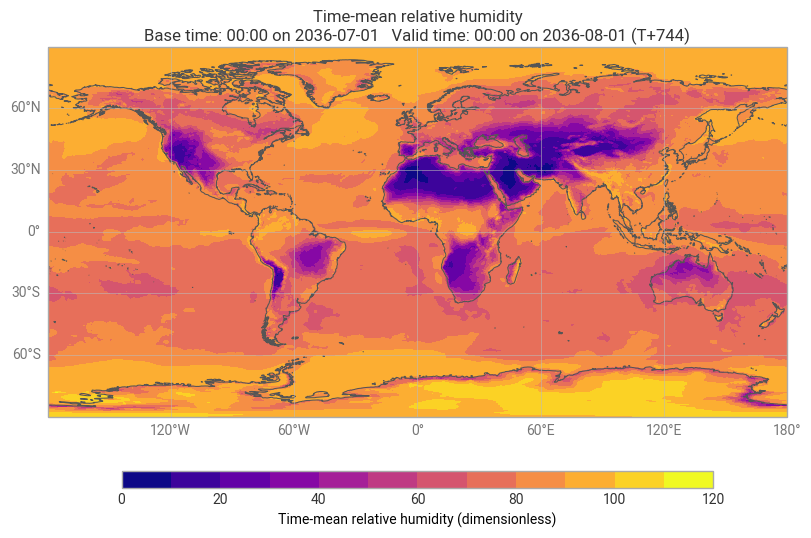

In [17]:
import earthkit.data
import earthkit.plots
import earthkit.regrid

data = earthkit.data.from_source("file", filename)
earthkit.plots.quickplot(data)